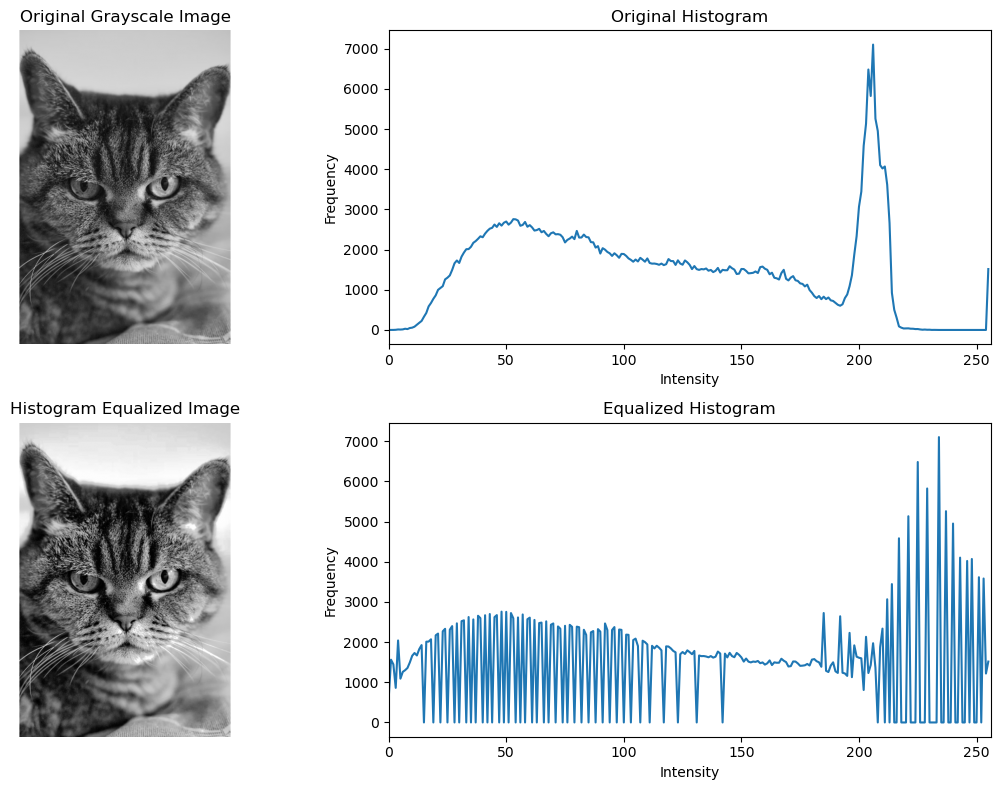

In [ ]:
import cv2
import matplotlib.pyplot as plt

# Read Image
image = cv2.imread("cat.png")

# Convert image to grayscale
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# 1. Generate Histogram
histogram = cv2.calcHist(
    [gray],
    [0],
    None,
    [256],
    [0, 256]
)

# 2. Histogram Equalization
equalized = cv2.equalizeHist(gray)

# 3. Histogram of Equalized Image
equalized_histogram = cv2.calcHist(
    [equalized],
    [0],
    None,
    [256],
    [0, 256]
)

# Display Images
plt.figure(figsize=(12, 8))

# Original Image
plt.subplot(2, 2, 1)
plt.imshow(gray, cmap="gray")
plt.title("Original Grayscale Image")
plt.axis("off")

# Original Histogram
plt.subplot(2, 2, 2)
plt.plot(histogram)
plt.title("Original Histogram")
plt.xlabel("Intensity")
plt.ylabel("Frequency")
plt.xlim([0, 256])

# Equalized Image
plt.subplot(2, 2, 3)
plt.imshow(equalized, cmap="gray")
plt.title("Histogram Equalized Image")
plt.axis("off")

# Equalized Histogram
plt.subplot(2, 2, 4)
plt.plot(equalized_histogram)
plt.title("Equalized Histogram")
plt.xlabel("Intensity")
plt.ylabel("Frequency")
plt.xlim([0, 256])

plt.tight_layout()
plt.show()

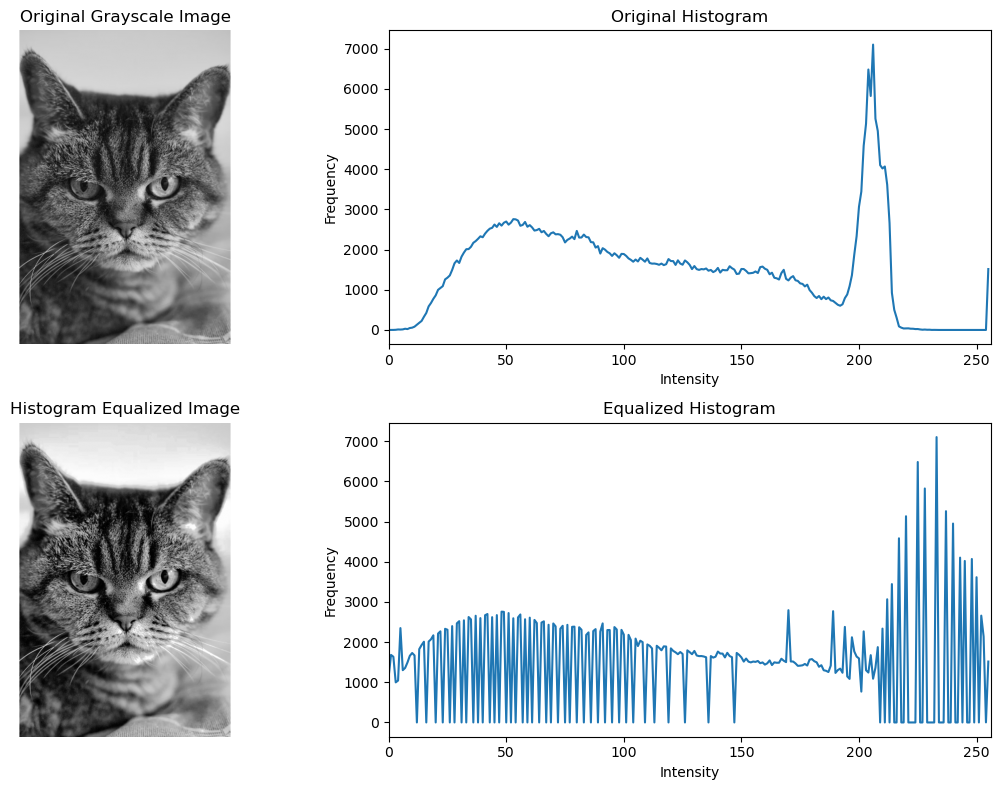

In [2]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# Read Image
image = cv2.imread("cat.png")

# Convert image to grayscale
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# 1. Generate Histogram (Manual Implementation)
def calculate_histogram(image):
    """Manually calculate histogram of an image"""
    histogram = np.zeros(256, dtype=np.float32)
    h, w = image.shape
    
    for i in range(h):
        for j in range(w):
            intensity = image[i, j]
            histogram[intensity] += 1
    
    return histogram.reshape(-1, 1)

histogram = calculate_histogram(gray)

# 2. Histogram Equalization (Manual Implementation)
def histogram_equalization(image):
    """Manually perform histogram equalization"""
    h, w = image.shape
    total_pixels = h * w
    
    # Calculate histogram
    histogram = np.zeros(256, dtype=np.float32)
    for i in range(h):
        for j in range(w):
            intensity = image[i, j]
            histogram[intensity] += 1
    
    # Calculate CDF (Cumulative Distribution Function)
    cdf = np.zeros(256, dtype=np.float32)
    cdf[0] = histogram[0]
    for i in range(1, 256):
        cdf[i] = cdf[i-1] + histogram[i]
    
    # Normalize CDF to [0, 255]
    cdf_normalized = (cdf / total_pixels) * 255
    
    # Create equalized image using lookup table
    equalized = np.zeros_like(image, dtype=np.uint8)
    for i in range(h):
        for j in range(w):
            old_intensity = image[i, j]
            equalized[i, j] = int(cdf_normalized[old_intensity])
    
    return equalized

equalized = histogram_equalization(gray)

# 3. Histogram of Equalized Image (Manual Implementation)
equalized_histogram = calculate_histogram(equalized)

# Display Images
plt.figure(figsize=(12, 8))

# Original Image
plt.subplot(2, 2, 1)
plt.imshow(gray, cmap="gray")
plt.title("Original Grayscale Image")
plt.axis("off")

# Original Histogram
plt.subplot(2, 2, 2)
plt.plot(histogram)
plt.title("Original Histogram")
plt.xlabel("Intensity")
plt.ylabel("Frequency")
plt.xlim([0, 256])

# Equalized Image
plt.subplot(2, 2, 3)
plt.imshow(equalized, cmap="gray")
plt.title("Histogram Equalized Image")
plt.axis("off")

# Equalized Histogram
plt.subplot(2, 2, 4)
plt.plot(equalized_histogram)
plt.title("Equalized Histogram")
plt.xlabel("Intensity")
plt.ylabel("Frequency")
plt.xlim([0, 256])

plt.tight_layout()
plt.show()